<a href="https://colab.research.google.com/github/hrutkabence/tutorials/blob/master/hungarian/field_courses/rts_gnss_observation_processing_hun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hídszerkezet vizsgálat GNSS és robot mérőállomás technikával
##Hídon végzett mérések feldolgozása - Szerkezetek geodéziája mérőgyakorlat

##Feldolgozáshoz szükséges python könyvtárak betöltése, letöltése

In [1]:
!pip install plotly

In [2]:
import re                         # szabályos kifejezésekhez
import numpy as np                # vektor/mátrix műveletekhez
import matplotlib.pyplot as plt   # grafikon készítéshez
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd               # táblázatszerű adatstruktúrákhoz
from datetime import datetime, timedelta, date  # időpontok és dátumok kezeléséhez

Töltsük fel a mérőállomásból exportált adatot a Google Colab-ba!

Ha nincs ilyen adatunk, használhatjuk a github-on megtalálható minta állományokat is!

In [16]:
!wget -q  https://raw.githubusercontent.com/hrutkabence/tutorials/master/hungarian/field_courses/RTS_raw.txt
!wget -q  https://raw.githubusercontent.com/hrutkabence/tutorials/master/hungarian/field_courses/GNSS_raw.txt

##Mérőállomás által rögzített mérési eredmények feldolgozása

Definiáljuk változóként a "nyers" robot mérőállomás méréseit tartalamzó szöveges fájlt. Ezt későbbiekben át fogjuk alakítani, így a kimenő fájl nevét is adjuk meg előre a feldolgozáshoz.

In [10]:
total_station_raw = 'RTS_raw.txt'
total_station = 'RTS.txt'


Jelenítsük meg a feltöltött fájl első 10 sorát:

In [17]:
with open(total_station_raw, 'r') as f:
    for i in range(10):
        line = f.readline()
        if not line:
            break
        print(line, end='')

1              0.0000   0.0000    0.0000    --------  0.000  15:23:26
7              1.00   1.00    1.00    --------  0.000  15:23:54
1              0.0000   0.0000    0.0000    --------  0.000  15:23:55
TPS1000        1.2383   198.3027    4.1187    --------  0.006  15:28:04
TPS1001        1.2384   198.3046    4.1207    --------  0.006  15:28:05
TPS1002        1.2377   198.3056    4.1217    --------  0.006  15:28:06
TPS1003        1.2382   198.3046    4.1226    --------  0.006  15:28:08
TPS1004        1.2394   198.3066    4.1243    --------  0.006  15:28:09
TPS1005        1.2380   198.3046    4.1244    --------  0.006  15:28:10
TPS1006        1.2381   198.3046    4.1252    --------  0.006  15:28:11


A koordináta-jegyzékben lehetnek olyan sorok (álláspont rekord), amiket nem akarunk belevenni a feldolgozásba. Ezeket törölhetjük manuálisan, vagy a folyamatos mérésnél beállított pontszámozás alapán is végezhetünk szűrést. (Pl.: minden olyan sort használjunk, ami 'TPS'-el kezdődik).

In [18]:
pattern1 = re.compile('TPS')        # a megadott mintázattal kezdődő sorok kiválasztásához

Sajnos a műszerből exportált szöveges fájl nem tökéletes. A szóközzel elválaszott állományban a perc és másodperc értékek, ha '10'-nél kisebbek, akkor egy szóköz karakterrel tárolódtak. További hiba a fájlban, hogy néhány esetben '60' mp értékek is szerepelnek, amit a Python hibaként kezelne le.


Készítsünk egy rövid Python programot, ami kezeli az előzőekben bemutatott hibákat a szöveges fájlban:

In [19]:
pattern = re.compile('[0-2][0-9]:[0-6][0-9]:60')    # időpontra vonatkozó adatok megkeresése óra:perc:mp formátum, ahol 0-29:0-59:0-60-ig vannak az egyes értékek
with open(total_station_raw) as fp:                 # bemenő fájl
  with open(total_station, 'w') as fo:              # kimenő fájl
    for line in fp:
      #if line.startswith('TPS'):
      if pattern1.match(line):                      # talált sor
        line = line.replace(': ', ':0')             # szóköz a percek vagy másodpercek között
        p = pattern.search(line)                    # vannak '60' másodperces érték?
        if p:                                       # ha van :60 másodperc a szövegben
          orig = p.group()                          # megtartjuk a talált részt
          tm = orig.replace(':60', ':59')           # kicseréljük a hibás részt
          t = datetime.strptime(tm, '%H:%M:%S') + timedelta(seconds=1)  # létező időpontra írjuk át, majd hozzáadjuk a 'levont' 1 mp értéket
          line = line.replace(orig, t.strftime('%H:%M:%S')) # visszaalakítjuk string-re és kicsréljük a hibás részt az eredi helyén
        print(line, end='', file=fo)                # elmentjük egy új fájlba az eredényt

Töltsük be az adatokat **pandas** tömbbe! Ügyeljünk arra, hogy az éppen aktuális dátum legyen megadva!

In [20]:
today_str = date.today().strftime('%Y-%m-%d')
print(today_str)

today_str='2022-04-04'             #TESZTELÉSHEZ át kell írni a dátumot, különben lekéri a éppen aktuálisat.
print(today_str)


2025-10-03
2022-04-04


Töltsük be a tömbbe az adatokat az éppen aktuális dátummal.

In [25]:
names = ["east", "north", "elev", "dummy", "std", "time"]
rts_data = pd.read_csv(total_station, sep=r'\s+', names=names, skiprows=3)
rts_data['time'] = pd.to_datetime(today_str + ' ' + rts_data['time'], format='%Y-%m-%d %H:%M:%S') # , format='%H:%M:%S')
print(f'{rts_data.shape[0]} records loaded!')
display(rts_data.head())

1606 records loaded!


,east,north,elev,dummy,std,time
TPS1003,1.2382,198.3046,4.1226,--------,0.006,2022-04-04 15:28:08
TPS1004,1.2394,198.3066,4.1243,--------,0.006,2022-04-04 15:28:09
TPS1005,1.2380,198.3046,4.1244,--------,0.006,2022-04-04 15:28:10
TPS1006,1.2381,198.3046,4.1252,--------,0.006,2022-04-04 15:28:11
TPS1007,1.2379,198.3065,4.1259,--------,0.006,2022-04-04 15:28:12


Ábrázoljuka a méréseket!

Előfordulhat, hogy a mérés nem lett leállítva időben, így a prizma leszerelése után a műszer talált egy másik prizmát. Emiatt egy nagy ugrás, lépcső jelenik meg a grafikonon a magasság adatokban. Töröljük manuálisan ezeket a rekordokat! Majd töltsük be újra az frissített adatokat a **pandas** tömbbe!

In [26]:
fig = px.line(rts_data, x='time', y='elev', title='Robot mérőállomással való mérés eredménye')
fig.update_layout(xaxis_title='Idő [hh:mm:ss]', yaxis_title='Magasság [m]')
fig.update_traces(line=dict(color='seagreen'), hovertemplate='Időpont: %{x}<br>Magasság: %{y:.3f} m')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Vajon van-e egyéb hiba a mérésben? Vannak-e szakadások (1 sec-nél nagyobb időközök)?

In [27]:
deltas = rts_data['time'].diff()[1:]          # az időkülönbség az előző rekordhoz képest
dd = deltas[deltas > timedelta(seconds=1)]    # válasszuk ki azokat a sorokat, ahol ez az érték nagyobb, mint 1 mp  (diff > 1 sec)
print(f'{rts_data.shape[0]} records with {dd.size} gaps!')

1606 records with 225 gaps!


Töltsük ki ezeket a szakadásokat interpolációval és írassuk ki a maximális lehajlás értékét!

In [28]:
t0 = rts_data['time'].min()
t0 = datetime(t0.year, t0.month, t0.day, 0, 0, 0)
dt = (rts_data['time'] - t0).dt.total_seconds()  # adott nap éjfélétől számolt eltelt idő kiszámítása
de = rts_data['elev'] - rts_data['elev'].max()
dt = dt.to_numpy().astype(int)
de = (de.to_numpy() * 1000).astype(int)   # átváltás mm-re
rts_x = np.arange(dt[0], dt[-1]+1)        # másodperc értékek sorozatának létrehozása a hiányzó intervallumra
rts_y = np.interp(rts_x, dt, de)          # hiányzó lehajlás értékek meghatározása (lineáris) interpolációval
print(f'Max deflection: {rts_y.min():.1f} mm')

Max deflection: -64.0 mm


Állítsunk be egy határértéket a lehetséges busz áthaladások detektálásához!

In [29]:
critical = -30 # mm                       általunk felvett kritikus lehajlás érték, ami fölött azt mondhatjuk, hogy egy/több busz áthaladt a hídközépen


Határozzuk meg, hogy mennyi ideig voltunk a megadott érték alatt!

In [30]:
rts = np.c_[rts_x, rts_y]                 # numpy mátrix x, y vektorokból
rts_bus = rts[rts[:,1] < critical]        # a kritikus értéket meghaladó lehajlások kiválasztása
print(f'{rts_bus.shape[0]} seconds under critical.')

521 seconds under critical.


Jelenítsük meg a lehajlás-idő grafikont kiemelve a kritikus lehajlás értékek helyét! A lehajlás értékeket a maxmális lehajlás értékből határozzuk meg.

In [31]:
fig = go.Figure()
fig.add_trace(go.Scattergl(x=rts_x, y=rts_y, mode='lines', name='Lehajlás'))
fig.add_trace(go.Scattergl(x=rts_bus[:,0], y=rts_bus[:,1], mode='markers', name=f'Kritikus értéket meghaladó ({critical} mm)',
                         marker=dict(color='darkred', size=5)))
fig.update_layout(title='Robot mérőállomással meghatározott lehajlások',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás [mm]')
fig.update_traces(line=dict(color='seagreen'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Hosszabb ideig tartó mérések esetén előfordulhat, hogy a  valamilyen trend jelenik meg (pl.: hőmérséklet-változás hatása miatt).
Vizsgáljuk meg, hogy a méréseinkben van-e trend, ha igen ezt távolítsuk el!

In [32]:
rts_y = rts_y - np.polyval(np.polyfit(rts_x, rts_y, 2), rts_x)  # tűntessük el a trendet az adatokból
rts_y = rts_y - rts_y.max()                                     # toljuk el a maximális lehajlás értéket nullába
print(f'max deflection: {rts_y.min():.1f} mm')
rts = np.c_[rts_x, rts_y]                                        # numpy mátrix x, y vektorokból
rts_bus = rts[rts[:,1] < critical]
print(f'{rts_bus.shape[0]} seconds under critical.')

max deflection: -64.3 mm
519 seconds under critical.


Ábrázoljuk a trendmentesített eredményt!

In [33]:
fig = go.Figure()
fig.add_trace(go.Scattergl(x=rts_x, y=rts_y, mode='lines', name='Lehajlás'))
fig.add_trace(go.Scattergl(x=rts_bus[:,0], y=rts_bus[:,1], mode='markers', name=f'Kritikus értéket meghaladó ({critical} mm)',
                         marker=dict(color='darkred', size=5)))
fig.update_layout(title='Robot mérőállomással meghatározott lehajlások trend eltűntetés után',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás mm')
fig.update_traces(line=dict(color='seagreen'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Végezetül próbáljuk meg deltálni a lehetséges busz áthaladásokat, mentsük el az eredményt egy fájlba!

In [34]:
start = 0                               # kezdősor indexe az első talált busznál
bus = []
for i in range(1, rts_bus.shape[0]):    # for ciklus minden sorra, kivéve az első sort
  if rts_bus[i,0] - rts_bus[i-1,0] > 1: # ha nagy a különbség (gap) -> új busz érkezett a hídközépre
    if i-start-1 > 2:                   # 2 másodpercnél tovább tartott az áthaladás?
      bus.append((np.average(rts_bus[start:i,0]),
                  np.min(rts_bus[start:i,1]),
                  i-start-1))           # tároljuk az időpontot [mp], max. lehajlást [mm] és annak az időtartamát [mp]
    start = i
# adjuk hozzá az utolsót
if rts_bus.shape[0] - start > 2:
  bus.append((np.average(rts_bus[start:,0]),
              np.min(rts_bus[start:,1]),
              rts_bus.shape[0]-start))
print(f'{len(bus)} busses found.')
print(f'Time  Max.defl.  Duration')
fo = open('rts_bus.txt', 'w')
for b in bus:
  print(f'{datetime.fromtimestamp(b[0]).strftime("%H:%M:%S"):8s} {b[1]:5.1f} {b[2]:5d}')
  print(f'{b[0]:.1f} {b[1]:.1f} {b[2]}', file=fo)
fo.close()

33 busses found.
Time  Max.defl.  Duration
15:28:44 -53.1    12
15:29:02 -31.8     5
15:29:20 -55.6    27
15:30:49 -54.6    32
15:32:27 -52.4    16
15:34:32 -35.2     5
15:35:24 -49.8    20
15:35:53 -46.6    10
15:36:38 -61.2    36
15:37:21 -56.0    27
15:40:28 -45.0     8
15:40:42 -60.0    10
15:41:08 -40.9    14
15:42:08 -37.7     4
15:42:46 -38.7    24
15:44:10 -45.5     8
15:44:55 -42.5    10
15:45:19 -47.5    10
15:46:00 -49.5    17
15:47:20 -35.6    18
15:48:50 -54.8    24
15:49:27 -42.9     6
15:50:01 -45.1    47
15:51:00 -44.3     8
15:51:49 -41.6     6
15:53:09 -30.1     4
15:53:17 -31.1     8
15:54:16 -37.5     8
15:54:44 -31.7     5
15:54:59 -48.8     8
15:55:54 -64.3    17
15:58:23 -43.7     8
15:58:48 -48.0    15


Jelenítsük meg a kapott eredményeket!

In [35]:
fig = go.Figure()
# Add the main deflection line
fig.add_trace(go.Scattergl(x=rts_x, y=rts_y, mode='lines', name='Lehajlás',
                         line=dict(color='seagreen'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')) # Set color and hovertemplate here

# Add the critical deflection line
fig.add_trace(go.Scattergl(x=[rts_x.min(), rts_x.max()], y=[critical, critical], mode='lines', name=f'Kritikus lehajlás ({critical} mm)',
                         line=dict(color='darkred', dash='dash')))

# Add markers for detected buses
fig.add_trace(go.Scattergl(x=[b[0] for b in bus], y=[b[1] for b in bus], mode='markers', name='Detektált busz',
                         marker=dict(color='darkred', size=8), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm'))

fig.update_layout(title='Robot mérőállomással meghatározott trendmentesített lehajlások és detektált buszok',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás mm')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

##GNSS mérés feldolgozása

A GNSS mérések feldolgozása nagyon hasonlít mérőállomással mért adatok feldolgozásához.

Definiáljuk az input/ouput változókat!

In [36]:
gnss_raw = 'GNSS_raw.txt'
gnss = 'GNSS.txt'

Jelenítsük meg a "nyers" fájl első 10 sorát!

In [42]:
with open(gnss_raw, 'r') as f:
    for i in range(10):
        line = f.readline()
        if not line:
            break
        print(line, end='')

RTCM-Ref 0207        650684.476   237444.172     137.177        --------   2021.10.08   15:38:14
GPS_Auto_3194        650133.267   238537.715     114.097        --------   2021.10.08   15:38:16
GPS_Auto_3195        650133.264   238537.714     114.106        --------   2021.10.08   15:38:17
GPS_Auto_3196        650133.267   238537.716     114.105        --------   2021.10.08   15:38:18
GPS_Auto_3197        650133.264   238537.718     114.098        --------   2021.10.08   15:38:19
GPS_Auto_3198        650133.266   238537.714     114.103        --------   2021.10.08   15:38:20
GPS_Auto_3199        650133.265   238537.713     114.102        --------   2021.10.08   15:38:21
GPS_Auto_3200        650133.265   238537.712     114.100        --------   2021.10.08   15:38:22
GPS_Auto_3201        650133.262   238537.719     114.112        --------   2021.10.08   15:38:23
GPS_Auto_3202        650133.263   238537.714     114.113        --------   2021.10.08   15:38:24


Adjuk meg a feldolgozásra szánt sorok kezdő karaktereit!

In [43]:
pattern1 = re.compile('GPS_Auto_')           # a megadott mintázattal kezdődő sorok kiválasztása

Ellenőrizzük a nyers adatokat. Ahol szükséges javítsük a "60" érték hibáját!

In [44]:
pattern = re.compile('[0-2][0-9]:[0-6][0-9]:60')  # időpontra vonatkozó adatok megkeresés
with open(gnss_raw) as fp:                        # bemenő fájl
  with open(gnss, 'w') as fo:                     # kimenő fájl
    for line in fp:
      if pattern1.match(line):                    # talált sor
        p = pattern.search(line)                  # van-e '60' másodperces érték?
        if p:                                     # ha van :60 másodperc a string-ben
          orig = p.group()                        # megtartjuk a talált részt
          tm = orig.replace(':60', ':59')         # kicseréljük a hibás részt
          t = datetime.strptime(tm, '%H:%M:%S') + timedelta(seconds=1)  # létező időpontra írjuk át, majd hozzáadjuk a 'levont' 1 mp értéket
          line = line.replace(orig, t.strftime('%H:%M:%S')) # visszaalakítjuk string-re és kicsréljük a hibás részt az eredi helyén
        print(line, end='', file=fo)              # elmentjük egy új fájlba az eredényt
!head -10 GNSS.txt

GPS_Auto_3194        650133.267   238537.715     114.097        --------   2021.10.08   15:38:16
GPS_Auto_3195        650133.264   238537.714     114.106        --------   2021.10.08   15:38:17
GPS_Auto_3196        650133.267   238537.716     114.105        --------   2021.10.08   15:38:18
GPS_Auto_3197        650133.264   238537.718     114.098        --------   2021.10.08   15:38:19
GPS_Auto_3198        650133.266   238537.714     114.103        --------   2021.10.08   15:38:20
GPS_Auto_3199        650133.265   238537.713     114.102        --------   2021.10.08   15:38:21
GPS_Auto_3200        650133.265   238537.712     114.100        --------   2021.10.08   15:38:22
GPS_Auto_3201        650133.262   238537.719     114.112        --------   2021.10.08   15:38:23
GPS_Auto_3202        650133.263   238537.714     114.113        --------   2021.10.08   15:38:24
GPS_Auto_3203        650133.261   238537.717     114.109        --------   2021.10.08   15:38:25


Töltsük be az adatainkat egy **pandas** tömbbe!
Ha nem sikerül az adatbetöltés, akkor az az eredeti fájlban találhatő formázott fejléc miatt lehetséges. Töröljük ezeket a sorokat!

In [45]:
names = ['id', 'east', 'north', 'elev', 'dummy', 'date', 'time']
gps_data = pd.read_csv(gnss, sep=r'\s+', names=names)
gps_data['time'] = pd.to_datetime(gps_data['date'] + ' ' + gps_data['time'])
gps_data.drop(columns=['dummy', 'date'], inplace=True)
display(gps_data.head())

,id,east,north,elev,time
0,GPS_Auto_3194,650133.267,238537.715,114.097,2021-10-08 15:38:16
1,GPS_Auto_3195,650133.264,238537.714,114.106,2021-10-08 15:38:17
2,GPS_Auto_3196,650133.267,238537.716,114.105,2021-10-08 15:38:18
3,GPS_Auto_3197,650133.264,238537.718,114.098,2021-10-08 15:38:19
4,GPS_Auto_3198,650133.266,238537.714,114.103,2021-10-08 15:38:20


Jelenítsük meg a GNSS méréseinket egy grafikonon!

In [46]:
fig = px.line(gps_data, x='time', y='elev', title='RTK-GNSS mérés eredménye')
fig.update_layout(xaxis_title='Idő [hh:mm:ss]', yaxis_title='Magasság [m]')
fig.update_traces(line=dict(color='steelblue'), hovertemplate='Időpont: %{x}<br>Magasság: %{y:.3f} mBf.')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Van-e szakadás?

In [47]:
deltas = gps_data['time'].diff()[1:]        # az időkülönbség az előző rekordhoz képest
dd = deltas[deltas > timedelta(seconds=1)]  # válasszuk ki azokat a sorokat, ahol ez az érték nagyobb, mint 1 mp  (diff > 1 sec)
print(f'{gps_data.shape[0]} records with {dd.size} gaps.')

1117 records with 5 gaps.


Javítsuk az esetleges szakadásokat interpolációval! Határozzuk meg a max. lehajlás értékét!

In [48]:
t0 = gps_data['time'].min()
t0 = datetime(t0.year, t0.month, t0.day, 0, 0, 0) # tartsuk meg a napot
dt = (gps_data['time'] - t0).dt.total_seconds()   # adott nap éjfélétől számolt eltelt idő kiszámítása
de = gps_data['elev'] - gps_data['elev'].max()
dt = dt.to_numpy().astype(int)
de = (de.to_numpy() * 1000).astype(int)   # váltsuk át mm-re
#gps_x = dt
#gps_y = de
gps_x = np.arange(dt[0], dt[-1]+1)        # másodperc értékek sorozatának létrehozása a hiányzó intervallumra
gps_y = np.interp(gps_x, dt, de)          # hiányzó lehajlás értékek meghatározása (lineáris) interpolációval
print(f'Max deflection: {gps_y.min():.1f} mm')

Max deflection: -75.0 mm


Állítsunk be egy határértéket az esetleges busz áthaladások detektálásához!

In [49]:
critical = -40                            # általunk felvett kritikus lehajlás érték, ami fölött azt mondhatjuk, hogy egy/több busz áthaladt a hídközépen

In [50]:
gps = np.c_[gps_x, gps_y]                 # numpy matrix az x, y vektorokból
gps_bus = gps[gps[:,1] < critical]        # a kritikus értéket meghaladó lehajlások kiválasztása
print(f'{gps_bus.shape[0]} seconds under critical.')

190 seconds under critical.


Jelenítsük meg a lehajlás-idő grafikont kiemelve a kritikus lehajlás értékek helyét! A lehajlás értékeket a maxmális magasság értékből határozzuk meg.

In [51]:
fig = go.Figure()
fig.add_trace(go.Scattergl(x=gps_x, y=gps_y, mode='lines', name='Lehajlás'))
fig.add_trace(go.Scattergl(x=gps_bus[:,0], y=gps_bus[:,1], mode='markers', name=f'Kritikus értéket meghaladó ({critical} mm)',
                         marker=dict(color='darkred', size=5)))
fig.update_layout(title='RTK-GNSS technikával meghatározott lehajlások',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás [mm]')
fig.update_traces(line=dict(color='steelblue'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Van-e trend?

In [52]:
gps_y = gps_y - np.polyval(np.polyfit(gps_x, gps_y, 2), gps_x)  # tűntessük el a trendet az adatokból
gps_y = gps_y - gps_y.max()                                     # toljuk el a maximális lehajlás értéket nullába
print(f'Max deflection: {gps_y.min():.1f} mm')
gps = np.c_[gps_x, gps_y]                                       # numpy mátrix x, y vektorokból
gpss_bus = gps[gps[:,1] < critical]
print(f'{gps_bus.shape[0]} seconds under critical.')

Max deflection: -79.9 mm
190 seconds under critical.


Ábrázoljuk az eredményeket!

In [53]:
fig = go.Figure()
fig.add_trace(go.Scattergl(x=gps_x, y=gps_y, mode='lines', name='Lehajlás'))
fig.add_trace(go.Scattergl(x=gps_bus[:,0], y=gps_bus[:,1], mode='markers', name=f'Kritikus értéket meghaladó ({critical} mm)',
                         marker=dict(color='darkred', size=5)))
fig.update_layout(title='RTK-GNSS technikával meghatározott lehajlások trendmentesítés után',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás [mm]')
fig.update_traces(line=dict(color='steelblue'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

Végezetül próbáljuk meg detektálni a lehetséges busz áthaladások időpontját és mentsük el ezeket egy külön fájlba!

In [54]:
start = 0                               # kezdősor indexe az első talált busznál
gbus = []
for i in range(1, gps_bus.shape[0]):    # for ciklus minden sorra, kivéve az első sort
  if gps_bus[i,0] - gps_bus[i-1,0] > 1: # ha nagy a különbség (gap) -> új busz érkezett a hídközépre
    if i-start-1 > 2:                   # 2 másodpercnél tovább tartott az áthaladás?
      gbus.append((np.average(gps_bus[start:i,0]),
                  np.min(gps_bus[start:i,1]),
                  i-start-1))           # tároljuk az időpontot [mp], max. lehajlást [mm] és annak az időtartamát [mp]
    start = i
# adjuk hozzá az utolsót
if gps_bus.shape[0] - start > 2:
  gbus.append((np.average(gps_bus[start:,0]),
              np.min(gps_bus[start:,1]),
              gps_bus.shape[0]-start))
print(f'{len(gbus)} busses found.')
print(f'Time  Max.defl.  Duration')
fo = open('gps_bus.txt', 'w')
for b in gbus:
  print(f'{datetime.fromtimestamp(b[0]).strftime("%H:%M:%S"):8s} {b[1]:5.1f} {b[2]:5d}')
  print(f'{b[0]:.1f} {b[1]:.1f} {b[2]}', file=fo)
fo.close()

18 busses found.
Time  Max.defl.  Duration
15:38:19 -52.0     6
15:40:26 -52.0     8
15:40:41 -70.0     9
15:41:09 -58.0    14
15:42:06 -51.0     5
15:42:41 -58.0    19
15:44:10 -51.0     5
15:44:53 -57.0     8
15:45:17 -55.0     7
15:46:01 -55.0    11
15:48:50 -61.0    15
15:49:58 -45.0     3
15:50:14 -49.0     4
15:50:58 -52.0     3
15:51:49 -51.0     4
15:54:17 -49.0     5
15:54:59 -61.0     5
15:55:54 -75.0    12


Ábrázoljuk a lehajlásokat és a busz áthaladásokat egy grafikonon!

In [55]:
fig = go.Figure()
# Add the main deflection line
fig.add_trace(go.Scattergl(x=gps_x, y=gps_y, mode='lines', name='Lehajlás',
                         line=dict(color='steelblue'), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm')) # Set color and hovertemplate here

# Add the critical deflection line
fig.add_trace(go.Scattergl(x=[gps_x.min(), gps_x.max()], y=[critical, critical], mode='lines', name=f'Kritikus lehajlás ({critical} mm)',
                         line=dict(color='darkred', dash='dash')))

# Add markers for detected buses
fig.add_trace(go.Scattergl(x=[b[0] for b in gbus], y=[b[1] for b in gbus], mode='markers', name='Detektált busz',
                         marker=dict(color='darkred', size=8), hovertemplate='Időpont: %{x}<br>Lehajlás: %{y:.0f} mm'))

fig.update_layout(title='RTK-GNSS technikával meghatározott, trendmentesített lehajlások és detektált buszok',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás [mm]')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()

# Robot mérőállomás vs. GNSS

Vizsgáljuk meg a robot mérőállomás és a GNSS vevő méréseiből meghatározott busz áthaladsok időpontjait. Keressünk azonos időpontokat!

In [56]:
i = 0   # index for rts bus
j = 0   # index for gps bus
ni = len(bus)
nj = len(gbus)
while True:
  if i < ni and j < nj:
    if bus[i][0] < gbus[j][0]:
      print(f'{datetime.fromtimestamp(bus[i][0]).strftime("%H:%M:%S"):8s} {bus[i][1]:5.1f} {bus[i][2]:5d} TPS')
      i += 1
    else:
      print(f'{datetime.fromtimestamp(gbus[j][0]).strftime("%H:%M:%S"):8s} {gbus[j][1]:5.1f} {gbus[j][2]:5d} GPS ***')
      j += 1
  elif i < ni:
    print(f'{datetime.fromtimestamp(bus[i][0]).strftime("%H:%M:%S"):8s} {bus[i][1]:5.1f} {bus[i][2]:5d} TPS')
    i += 1
  elif j < nj:
    print(f'{datetime.fromtimestamp(gbus[j][0]).strftime("%H:%M:%S"):8s} {gbus[j][1]:5.1f} {gbus[j][2]:5d} GPS ***')
    j += 1
  else:
    break

15:28:44 -53.1    12 TPS
15:29:02 -31.8     5 TPS
15:29:20 -55.6    27 TPS
15:30:49 -54.6    32 TPS
15:32:27 -52.4    16 TPS
15:34:32 -35.2     5 TPS
15:35:24 -49.8    20 TPS
15:35:53 -46.6    10 TPS
15:36:38 -61.2    36 TPS
15:37:21 -56.0    27 TPS
15:38:19 -52.0     6 GPS ***
15:40:26 -52.0     8 GPS ***
15:40:28 -45.0     8 TPS
15:40:41 -70.0     9 GPS ***
15:40:42 -60.0    10 TPS
15:41:08 -40.9    14 TPS
15:41:09 -58.0    14 GPS ***
15:42:06 -51.0     5 GPS ***
15:42:08 -37.7     4 TPS
15:42:41 -58.0    19 GPS ***
15:42:46 -38.7    24 TPS
15:44:10 -45.5     8 TPS
15:44:10 -51.0     5 GPS ***
15:44:53 -57.0     8 GPS ***
15:44:55 -42.5    10 TPS
15:45:17 -55.0     7 GPS ***
15:45:19 -47.5    10 TPS
15:46:00 -49.5    17 TPS
15:46:01 -55.0    11 GPS ***
15:47:20 -35.6    18 TPS
15:48:50 -54.8    24 TPS
15:48:50 -61.0    15 GPS ***
15:49:27 -42.9     6 TPS
15:49:58 -45.0     3 GPS ***
15:50:01 -45.1    47 TPS
15:50:14 -49.0     4 GPS ***
15:50:58 -52.0     3 GPS ***
15:51:00 -44.3     

[Keresztkorreláció](https://en.wikipedia.org/wiki/Cross-correlation) segítségével vizsgáljuk meg, hogy mennyire szoros a kapcsolat a mérőállomás és a GNSS vevő mérései között.

![CrossCorrGIF](https://upload.wikimedia.org/wikipedia/commons/9/98/Cross_Correlation_Animation.gif?20220310033723)

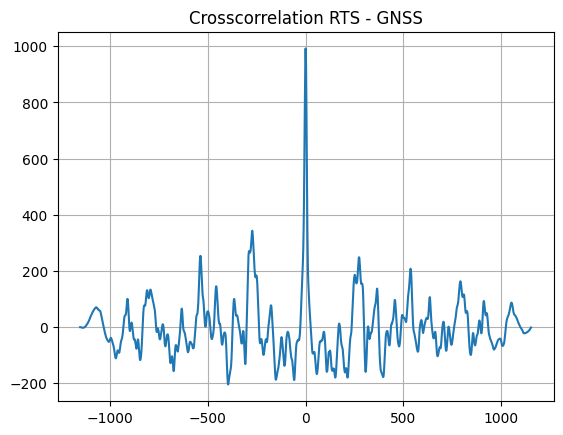

The time offset between RTS and GNSS data: 0 seconds.


In [57]:
def cross_corr(x1, y1, x2, y2):
    """ calculate normalized cross correlation between two data series

        :param x1: first data x
        :param y1: first data y
        :param x2: second data x
        :param y2: second data y
        :return lags and correlations
    """
    # find common range in x
    xmin = max(x1[0], x2[0])
    xmax = min(x1[-1], x2[-1])
    n = int(xmax - xmin)   # időtartam mp-ben
    x = np.linspace(xmin, xmax, n)
    yy1 = np.interp(x, x1, y1)
    yy2 = np.interp(x, x2, y2)
    yy1 = (yy1 - np.mean(yy1)) / (np.std(yy1))
    yy2 = (yy2 - np.mean(yy2)) / np.std(yy2)
    corr = np.correlate(yy1, yy2, "full")
    lags = np.arange(-n + 1, n)
    return lags, corr

lags, corr = cross_corr(rts_x, rts_y, gps_x, gps_y)
plt.plot(lags, corr)
plt.grid()
plt.title("Crosscorrelation RTS - GNSS")
plt.show()
print(f'The time offset between RTS and GNSS data: {lags[np.argmax(corr)]} seconds.')


Láthatjuk, hogy az időszinkron miatt a két adatsor elcsúszása minimális, pár mp körül van.

Generáljunk mesterséges eltolást! Megtudjuk határozni kereszkorreláció segítségével az így létrehozott eltolás értékét?

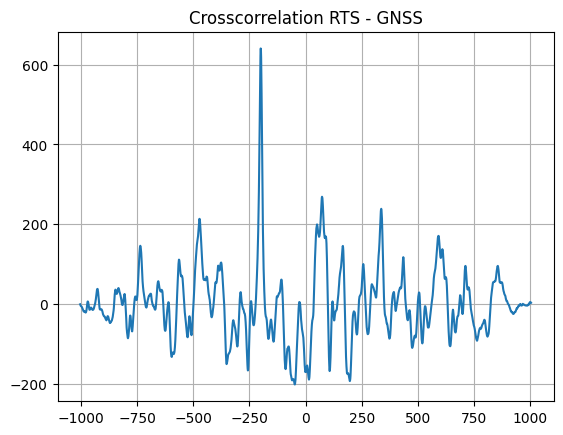

The time offset between RTS and GNSS data: -200 seconds.


In [63]:
shift_rts_x_test = rts_x - 200   # eltolás 200 mp-el

lags_test, corr_test = cross_corr(shift_rts_x_test[150:], rts_y[150:], gps_x[:-149], gps_y[:-149])
plt.plot(lags_test, corr_test)
plt.grid()
plt.title("Crosscorrelation RTS - GNSS")
plt.show()
print(f'The time offset between RTS and GNSS data: {lags_test[np.argmax(corr_test)]} seconds.')

Az eredeti mérésekre meghatározott eltolással korrigáljuk a méréseket.

In [61]:
time_shift = lags[np.argmax(corr)]
print(f'Időeltolás értéke: {time_shift} sec.')

Időeltolás értéke: 0 sec.


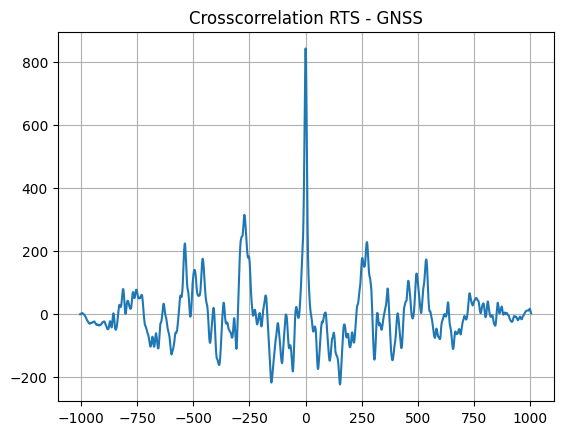

The time offset between RTS and GNSS data: 0 seconds.


In [64]:
shift_rts_x = rts_x - time_shift
lags, corr = cross_corr(shift_rts_x[150:], rts_y[150:], gps_x[:-149], gps_y[:-149])
plt.plot(lags, corr)
plt.grid()
plt.title("Crosscorrelation RTS - GNSS")
plt.show()
print(f'The time offset between RTS and GNSS data: {lags[np.argmax(corr)]} seconds.')

Ábrázoljuk a robot mérőállomással és GNSS technikával meghatározott lehajlásokat egy grafikonon!

In [65]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scattergl(x=shift_rts_x, y=rts_y, mode='lines', name='Trendmentes RTS lehajlás',
            line=dict(color='seagreen'), hovertemplate='Időpont: %{x}<br>RTS lehajlás: %{y:.0f} [mm]'))
fig.add_trace(go.Scattergl(x=gps_x, y=gps_y, mode='lines', name='Trendmentes GNSS lehajlás',
               line=dict(color='steelblue'), hovertemplate='Időpont: %{x}<br>GNSS lehajlás: %{y:.0f} [mm]'))
fig.update_layout(title='Trendmentesített lehajlások: robot mérőállomás vs. RTK-GNSS',
                  xaxis_title='Idő [sec - éjféltől számított]',
                  yaxis_title='Lehajlás [mm]')
fig.update_xaxes(rangeslider_visible=True, gridcolor='lightgrey')
fig.update_yaxes(gridcolor='lightgrey')
fig.update_layout(plot_bgcolor='white')
fig.show()